# Red Veterinaria Mexikans  
## Generación del Dataset

En este notebook genero un dataset sintético que simula las operaciones de una red nacional de clínicas veterinarias en México.

Mexikans opera una red de **50 clínicas veterinarias en múltiples ciudades mexicanas**. El objetivo de este dataset es simular de forma realista:

- operaciones de clínicas veterinarias
- comportamiento de clientes y mascotas
- patrones de demanda de servicios
- métricas de desempeño operativo

El proceso de generación de datos está diseñado para imitar patrones del mundo real observados en las operaciones de atención veterinaria, incluyendo:

- fluctuaciones estacionales de la demanda
- campañas de vacunación
- estacionalidad de enfermedades
- restricciones de capacidad de las clínicas
- variabilidad operativa

El dataset generado en este notebook será utilizado a lo largo del proyecto para:

- análisis exploratorio de datos
- ingeniería de características
- segmentación de clínicas
- pronóstico de demanda
- explicabilidad de modelos

Todos los datasets producidos aquí serán exportados al directorio **data/** y utilizados por los siguientes notebooks del proyecto.

In [1]:
"""
Configuración del Entorno
"""

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

NOTEBOOK_ID = "01_data_generation"

FIGURES_DIR = Path("../figures")

def save_plot(name):

    folder = FIGURES_DIR / NOTEBOOK_ID
    folder.mkdir(parents=True, exist_ok=True)

    plt.savefig(
        folder / f"{name}.png",
        dpi=300,
        bbox_inches="tight")

from datetime import datetime, timedelta

np.random.seed(42)

pd.set_option("display.max_columns", None)

print("Entorno listo.")

Entorno listo.


## Configuración de Ciudades Mexicanas

La red veterinaria Mexikans opera clínicas en varias ciudades importantes de México.

Cada ciudad tiene sus propias características que influyen en la demanda veterinaria y en los niveles de precios.  
Para simular estas diferencias, asigno dos factores a cada ciudad:

**Factor de Población**

Representa el tamaño relativo de la población y los niveles de tenencia de mascotas en la ciudad.  
Las ciudades con factores de población más altos generarán mayor demanda veterinaria.

**Factor de Precio**

Representa las diferencias locales de precios para los servicios veterinarios.  
Las grandes áreas metropolitanas normalmente tienen precios de servicios más altos.

Estos factores influirán tanto en la **generación de demanda** como en los **cálculos de ingresos de las clínicas** más adelante en la simulación.

In [2]:
"""
Configuración de Ciudades Mexicanas
"""

cities_data = [
    ("Ciudad de México", "CDMX", 1.40, 1.25),
    ("Guadalajara", "Jalisco", 1.20, 1.15),
    ("Monterrey", "Nuevo León", 1.25, 1.20),
    ("Puebla", "Puebla", 1.00, 1.00),
    ("Tijuana", "Baja California", 1.10, 1.05),
    ("Mérida", "Yucatán", 0.90, 0.95),
    ("Cancún", "Quintana Roo", 0.95, 1.05),
    ("Querétaro", "Querétaro", 1.00, 1.05),
    ("León", "Guanajuato", 0.95, 0.95),
    ("Chihuahua", "Chihuahua", 0.90, 0.95),
    ("Hermosillo", "Sonora", 0.90, 0.95),
    ("Toluca", "Estado de México", 0.95, 0.95),
    ("San Luis Potosí", "San Luis Potosí", 0.90, 0.95),
    ("Aguascalientes", "Aguascalientes", 0.90, 0.95)
]

cities_df = pd.DataFrame(
    cities_data,
    columns=[
        "city",
        "state",
        "population_factor",
        "price_factor"
    ]
)

print("Ciudades configuradas:", len(cities_df))

cities_df.head()

Ciudades configuradas: 14


,city,state,population_factor,price_factor
0,Ciudad de México,CDMX,1.40,1.25
1,Guadalajara,Jalisco,1.20,1.15
2,Monterrey,Nuevo León,1.25,1.20
3,Puebla,Puebla,1.00,1.00
4,Tijuana,Baja California,1.10,1.05


## Generación de Clínicas Veterinarias

La red Mexikans está compuesta por **50 clínicas veterinarias distribuidas en múltiples ciudades de México**.

Cada clínica tiene características operativas únicas que influyen en su desempeño y capacidad de servicio.

Se generan los siguientes atributos para cada clínica:

**Número de Veterinarios**

Representa el tamaño del personal de la clínica.  
Más veterinarios permiten que la clínica atienda a más pacientes por día.

**Capacidad de la Clínica**

El número máximo de pacientes que la clínica puede atender por día.  
La capacidad depende del número de veterinarios y de la eficiencia operativa.

**Popularidad de la Clínica**

Representa diferencias en reputación, accesibilidad y lealtad de los clientes.  
Las clínicas con mayor popularidad tienden a atraer más pacientes.

**Servicios de Emergencia**

No todas las clínicas ofrecen atención de emergencia. Las clínicas más grandes tienen mayor probabilidad de atender visitas de emergencia.

Estas variaciones crean diferencias realistas en el desempeño de las clínicas dentro de la red.

In [3]:
"""
Generación de Clínicas Veterinarias
"""

n_clinics = 50

clinic_rows = []

for i in range(n_clinics):

    clinic_id = f"C{i+1:03d}"

    city_row = cities_df.sample(1).iloc[0]
    city = city_row["city"]

    number_of_veterinarians = np.random.randint(2,7)

    patients_per_vet = np.random.randint(8,12)

    clinic_capacity = number_of_veterinarians * patients_per_vet

    clinic_popularity = np.random.uniform(0.8,1.2)

    opening_year = np.random.randint(2010,2024)

    emergency_enabled = np.random.rand() < 0.35

    clinic_rows.append({
        "clinic_id": clinic_id,
        "city": city,
        "number_of_veterinarians": number_of_veterinarians,
        "clinic_capacity": clinic_capacity,
        "clinic_popularity": clinic_popularity,
        "opening_year": opening_year,
        "emergency_enabled": emergency_enabled
    })

clinics_df = pd.DataFrame(clinic_rows)

print("Clínicas generadas:", len(clinics_df))

clinics_df.head()

Clínicas generadas: 50


,clinic_id,city,number_of_veterinarians,clinic_capacity,clinic_popularity,opening_year,emergency_enabled
0,C001,Chihuahua,4,36,0.822565,2017,False
1,C002,San Luis Potosí,3,33,0.916858,2023,True
2,C003,Chihuahua,5,40,1.186253,2011,False
3,C004,San Luis Potosí,5,45,0.970062,2015,False
4,C005,Tijuana,6,66,1.098928,2014,False


## Configuración de Servicios Veterinarios

Las clínicas veterinarias ofrecen una variedad de servicios médicos que difieren en complejidad, duración y costo.

Para simular este entorno, defino un conjunto de servicios veterinarios comúnmente ofrecidos en las clínicas.

Cada servicio incluye:

**Costo Promedio del Tratamiento**

Representa el precio base del procedimiento médico.

**Costo Promedio de Medicamentos**

Representa el costo promedio de los medicamentos recetados durante la visita.

**Complejidad del Servicio**

Indica la complejidad operativa del servicio.

Este atributo será útil más adelante al analizar la eficiencia operativa y el desempeño de las clínicas.

In [4]:
"""
Configuración de Servicios Veterinarios
"""

services_data = [

    ("General Consultation", 40, 15, "Low"),
    ("Vaccination", 30, 10, "Low"),
    ("Lab Tests", 70, 20, "Medium"),
    ("Dental Cleaning", 120, 25, "Medium"),
    ("Minor Surgery", 250, 80, "High"),
    ("Major Surgery", 600, 200, "High"),
    ("Imaging", 150, 30, "Medium"),
    ("Emergency Care", 180, 50, "High")

]

services_df = pd.DataFrame(
    services_data,
    columns=[
        "service_type",
        "avg_treatment_cost",
        "avg_medication_cost",
        "complexity"
    ]
)

print("Servicios configurados:", len(services_df))

services_df

Servicios configurados: 8


,service_type,avg_treatment_cost,avg_medication_cost,complexity
0,General Consultation,40,15,Low
1,Vaccination,30,10,Low
2,Lab Tests,70,20,Medium
3,Dental Cleaning,120,25,Medium
4,Minor Surgery,250,80,High
5,Major Surgery,600,200,High
6,Imaging,150,30,Medium
7,Emergency Care,180,50,High


## Generación de la Población de Mascotas

Las clínicas veterinarias atienden a una población de mascotas que pertenecen a clientes individuales.

Para simular este entorno, genero una población sintética de mascotas que representa la base de pacientes de la red Mexikans.

Cada mascota incluye los siguientes atributos:

**Tipo de Mascota**

Las principales categorías de animales atendidos en clínicas veterinarias:

- Perros
- Gatos
- Animales exóticos

**Raza**

Se generan diferentes razas para cada tipo de mascota.

**Edad**

La edad de la mascota influye en la demanda de atención médica y en los servicios veterinarios.

Las mascotas se clasifican en:

- Jóvenes (0–2 años)
- Adultas (3–8 años)
- Senior (9+ años)

**Clínica Principal**

La mayoría de los dueños de mascotas visitan de forma consistente la misma clínica veterinaria.  
Para simular este comportamiento, a cada mascota se le asigna una clínica preferida.

In [5]:
"""
Generación de la Población de Mascotas
"""

n_pets = 25000

pet_types = ["Perro", "Gato", "Exótico"]
pet_type_probs = [0.6, 0.3, 0.1]

dog_breeds = [
"Labrador Retriever","Pastor Alemán","Golden Retriever","Bulldog Francés",
"Caniche","Bulldog","Beagle","Rottweiler","Dachshund","Husky Siberiano",
"Gran Danés","Doberman","Border Collie","Shih Tzu","Chihuahua",
"Cocker Spaniel","Pastor Australiano","Maltés","Pomerania","Bóxer",
"Boston Terrier","Boyero de Berna","Basset Hound","San Bernardo","Akita"
]

cat_breeds = [
"Gato Doméstico de Pelo Corto","Siamés","Persa","Maine Coon","Ragdoll",
"Bengalí","Sphynx","British Shorthair","Abisinio","Scottish Fold",
"Azul Ruso","Birmano","Oriental de Pelo Corto","Bosque de Noruega","Devon Rex"
]

exotic_types = [
"Conejo","Hámster","Cobaya","Hurón","Loro",
"Cacatúa Ninfa","Iguana","Tortuga","Serpiente","Chinchilla",
"Erizo","Gecko"
]

pet_rows = []

for i in range(n_pets):

    pet_id = f"P{i+1:06d}"

    customer_id = f"CU{np.random.randint(1,18000):05d}"

    pet_type = np.random.choice(pet_types, p=pet_type_probs)

    if pet_type == "Perro":
        breed = np.random.choice(dog_breeds)

    elif pet_type == "Gato":
        breed = np.random.choice(cat_breeds)

    else:
        breed = np.random.choice(exotic_types)

    age = int(np.clip(np.random.normal(5,3),0,16))

    if age <= 2:
        age_group = "Joven"
    elif age <= 8:
        age_group = "Adulto"
    else:
        age_group = "Senior"

    primary_clinic = np.random.choice(clinics_df["clinic_id"])

    pet_rows.append({
        "pet_id": pet_id,
        "customer_id": customer_id,
        "pet_type": pet_type,
        "pet_breed": breed,
        "pet_age": age,
        "pet_age_group": age_group,
        "primary_clinic": primary_clinic
    })

pets_df = pd.DataFrame(pet_rows)

print("Número de mascotas:", len(pets_df))

pets_df.head()

Número de mascotas: 25000


,pet_id,customer_id,pet_type,pet_breed,pet_age,pet_age_group,primary_clinic
0,P000001,CU06810,Perro,San Bernardo,6,Adulto,C023
1,P000002,CU05871,Perro,Maltés,2,Joven,C038
2,P000003,CU06883,Perro,Akita,2,Joven,C039
3,P000004,CU17681,Perro,Doberman,6,Adulto,C025
4,P000005,CU06289,Perro,Akita,8,Adulto,C045


## Generación del Calendario

La demanda en clínicas veterinarias varía a lo largo del tiempo debido a patrones estacionales y campañas de salud.

Para simular estas dinámicas, genero un dataset de calendario que cubre todo el período de simulación.

Cada fecha incluye atributos que influyen en la demanda veterinaria:

**Día de la Semana**

La demanda tiende a aumentar durante los fines de semana porque los dueños de mascotas tienen más disponibilidad para visitar las clínicas.

**Estación**

La estacionalidad puede influir en ciertas condiciones veterinarias.

**Campañas de Vacunación**

Las campañas de vacunación preventiva suelen ocurrir durante los meses de primavera.

**Temporada de Enfermedades**

Algunas enfermedades veterinarias son más comunes durante los meses más cálidos.

**Crecimiento de la Demanda**

Con el tiempo, la demanda veterinaria tiende a crecer debido al aumento en la tenencia de mascotas y a una mayor conciencia sobre la atención preventiva.

In [6]:
"""
Generación del Calendario
"""

start_date = "2020-01-01"
end_date = "2024-12-31"

calendar_df = pd.DataFrame({
    "visit_date": pd.date_range(start=start_date, end=end_date)
})

calendar_df["year"] = calendar_df["visit_date"].dt.year
calendar_df["month"] = calendar_df["visit_date"].dt.month
calendar_df["day_of_week"] = calendar_df["visit_date"].dt.day_name()

calendar_df["is_weekend"] = calendar_df["day_of_week"].isin(
    ["Saturday", "Sunday"]
).astype(int)

def get_season(month):

    if month in [12,1,2]:
        return "Invierno"

    elif month in [3,4,5]:
        return "Primavera"

    elif month in [6,7,8]:
        return "Verano"

    else:
        return "Otoño"

calendar_df["season"] = calendar_df["month"].apply(get_season)

calendar_df["vaccination_campaign"] = calendar_df["month"].isin([3,4,5]).astype(int)

calendar_df["disease_season"] = calendar_df["month"].isin([6,7,8]).astype(int)

calendar_df["holiday_indicator"] = calendar_df["month"].isin([12]).astype(int)

calendar_df["year_growth_factor"] = 1 + (
    (calendar_df["year"] - calendar_df["year"].min()) * 0.04
)

print("Filas del calendario:", len(calendar_df))

calendar_df.head()

Filas del calendario: 1827


,visit_date,year,month,day_of_week,is_weekend,season,vaccination_campaign,disease_season,holiday_indicator,year_growth_factor
0,2020-01-01,2020,1,Wednesday,0,Invierno,0,0,0,1.0
1,2020-01-02,2020,1,Thursday,0,Invierno,0,0,0,1.0
2,2020-01-03,2020,1,Friday,0,Invierno,0,0,0,1.0
3,2020-01-04,2020,1,Saturday,1,Invierno,0,0,0,1.0
4,2020-01-05,2020,1,Sunday,1,Invierno,0,0,0,1.0


## Generación de Demanda Diaria

Con la red de clínicas, la población de mascotas y el calendario definidos, ahora simulo el número esperado de visitas veterinarias por clínica para cada día del período de simulación.

Varios factores influyen en la demanda diaria:

**Capacidad de la Clínica**

Las clínicas con más veterinarios pueden atender a más pacientes.

**Factor de Población de la Ciudad**

Las ciudades con poblaciones más grandes tienden a generar mayor demanda veterinaria.

**Popularidad de la Clínica**

Algunas clínicas atraen más pacientes debido a su reputación, accesibilidad o lealtad de los clientes.

**Efectos Temporales**

La demanda varía dependiendo de:

- fines de semana
- campañas de vacunación
- enfermedades estacionales
- tendencias de crecimiento a largo plazo

Las visitas diarias se simulan utilizando una **distribución de Poisson**, comúnmente utilizada para modelar conteos de eventos en sistemas de salud.

Se aplica una **restricción de capacidad suave** para evitar escenarios poco realistas en los que las clínicas operen exactamente al 100% de su capacidad todos los días.

In [7]:
"""
Generación de Demanda Diaria
"""

daily_rows = []

weekday_factors = {
    "Monday": 0.85,
    "Tuesday": 0.95,
    "Wednesday": 1.00,
    "Thursday": 0.95,
    "Friday": 1.10,
    "Saturday": 1.25,
    "Sunday": 1.15
}

for _, clinic in clinics_df.iterrows():

    clinic_id = clinic["clinic_id"]
    clinic_capacity = clinic["clinic_capacity"]
    clinic_popularity = clinic["clinic_popularity"]
    city = clinic["city"]

    city_factor = cities_df.loc[
        cities_df["city"] == city,
        "population_factor"
    ].values[0]

    for _, day in calendar_df.iterrows():

        visit_date = day["visit_date"]

        weekday_factor = weekday_factors[day["day_of_week"]]
        vaccination_factor = 1.15 if day["vaccination_campaign"] else 1.0
        disease_factor = 1.10 if day["disease_season"] else 1.0
        growth_factor = day["year_growth_factor"]

        base_lambda = clinic_capacity * 0.55

        demand_lambda = (
            base_lambda
            * city_factor
            * clinic_popularity
            * weekday_factor
            * vaccination_factor
            * disease_factor
            * growth_factor
        )

        visits = np.random.poisson(demand_lambda)

        """
        Restricción suave de capacidad de la clínica

        Las clínicas rara vez operan exactamente al 100% de su capacidad debido a:
        - cancelaciones de citas
        - pacientes que no se presentan
        - márgenes operativos de seguridad
        """

        max_capacity = max(
            1,
            int(clinic_capacity * np.random.uniform(0.90, 0.98))
        )

        visits = min(visits, max_capacity)

        daily_rows.append({
            "clinic_id": clinic_id,
            "visit_date": visit_date,
            "expected_visits": visits
        })

daily_demand_df = pd.DataFrame(daily_rows)

print("Filas de demanda diaria:", len(daily_demand_df))

daily_demand_df.head()

Filas de demanda diaria: 91350


,clinic_id,visit_date,expected_visits
0,C001,2020-01-01,14
1,C001,2020-01-02,16
2,C001,2020-01-03,14
3,C001,2020-01-04,16
4,C001,2020-01-05,21


## Generación de Visitas Veterinarias

Con la demanda diaria de las clínicas simulada, ahora genero visitas veterinarias individuales.

Cada fila en el dataset de visitas representa una sola cita veterinaria.

El proceso de generación simula varios comportamientos operativos realistas.

### Selección de Mascotas

Las mascotas se seleccionan de la población sintética de mascotas.

La mayoría de las mascotas visitan su **clínica principal**, lo que refleja el comportamiento real de lealtad de los clientes.

### Asignación de Servicios

El tipo de servicio veterinario depende del **tipo de mascota**.

Por ejemplo:

- Los perros requieren más vacunaciones y cirugías
- Los gatos requieren más consultas y pruebas de laboratorio
- Los animales exóticos requieren más estudios de imagen y atención especializada

### Simulación de Costos

Los costos de tratamiento y medicamentos se simulan utilizando distribuciones log-normales, que representan mejor la variabilidad real de los precios en la atención médica.

### Tipo de Cita

Las visitas pueden ocurrir como:

- citas programadas
- visitas sin cita (walk-in)

Las visitas de emergencia siempre ocurren sin cita previa.

Este proceso produce un dataset a nivel transaccional que representa la actividad de las clínicas veterinarias en toda la red Mexikans.

## Generación de Visitas Veterinarias

Con la demanda diaria de las clínicas simulada, ahora genero visitas veterinarias individuales.

Cada fila en el dataset de visitas representa una sola cita veterinaria.

El proceso de generación simula varios comportamientos operativos realistas.

### Selección de Mascotas

Las mascotas se seleccionan de la población sintética de mascotas.

La mayoría de las mascotas visitan su **clínica principal**, reflejando el comportamiento real de lealtad de los clientes.

### Asignación de Servicios

El tipo de servicio veterinario depende del **tipo de mascota**.

Por ejemplo:

- Los perros requieren más vacunaciones y cirugías
- Los gatos requieren más consultas y pruebas de laboratorio
- Los animales exóticos requieren más estudios de imagen y atención especializada

### Simulación de Costos

Los costos de tratamiento y medicamentos se simulan utilizando distribuciones lognormales, que representan mejor la variabilidad real de los precios en la atención médica.

### Tipo de Cita

Las visitas pueden ocurrir como:

- citas programadas
- visitas sin cita (walk-in)

Las visitas de emergencia siempre ocurren sin cita previa.

Este proceso produce un dataset a nivel transaccional que representa la actividad de las clínicas veterinarias en toda la red Mexikans.

In [8]:
"""
Generar Visitas Veterinarias
"""

visit_rows = []
visit_id_counter = 1


# Probabilidades de servicio por tipo de mascota

dog_service_probs = {
    "General Consultation":0.30,
    "Vaccination":0.25,
    "Lab Tests":0.10,
    "Dental Cleaning":0.10,
    "Minor Surgery":0.10,
    "Major Surgery":0.07,
    "Imaging":0.05,
    "Emergency Care":0.03
}

cat_service_probs = {
    "General Consultation":0.40,
    "Vaccination":0.20,
    "Lab Tests":0.15,
    "Dental Cleaning":0.05,
    "Minor Surgery":0.07,
    "Major Surgery":0.03,
    "Imaging":0.07,
    "Emergency Care":0.03
}

exotic_service_probs = {
    "General Consultation":0.30,
    "Vaccination":0.10,
    "Lab Tests":0.20,
    "Dental Cleaning":0.02,
    "Minor Surgery":0.05,
    "Major Surgery":0.03,
    "Imaging":0.20,
    "Emergency Care":0.10
}


service_lookup = services_df.set_index("service_type").to_dict("index")
price_lookup = cities_df.set_index("city")["price_factor"].to_dict()

clinic_city_lookup = clinics_df.set_index("clinic_id")["city"].to_dict()
clinic_emergency_lookup = clinics_df.set_index("clinic_id")["emergency_enabled"].to_dict()

pet_primary_lookup = pets_df.groupby("primary_clinic").indices


for _, row in daily_demand_df.iterrows():

    clinic_id = row["clinic_id"]
    visit_date = row["visit_date"]
    n_visits = row["expected_visits"]

    clinic_city = clinic_city_lookup[clinic_id]
    price_factor = price_lookup[clinic_city]
    emergency_enabled = clinic_emergency_lookup[clinic_id]


    for _ in range(n_visits):

        # Comportamiento de lealtad (la mayoría de las mascotas visitan su clínica principal)

        if np.random.rand() < 0.8 and clinic_id in pet_primary_lookup:

            pet_index = np.random.choice(pet_primary_lookup[clinic_id])
            pet = pets_df.iloc[pet_index]

        else:

            pet = pets_df.sample(1).iloc[0]


        pet_id = pet["pet_id"]
        customer_id = pet["customer_id"]
        pet_type = pet["pet_type"]
        pet_age_group = pet["pet_age_group"]


        """
        Frecuencia realista de visitas según tipo de mascota y edad
        """

        if pet_type == "Perro":

            if pet_age_group == "Joven":
                visit_probability = np.random.uniform(0.35,0.55)

            elif pet_age_group == "Adulto":
                visit_probability = np.random.uniform(0.30,0.50)

            else:
                visit_probability = np.random.uniform(0.40,0.60)


        elif pet_type == "Gato":

            if pet_age_group == "Joven":
                visit_probability = np.random.uniform(0.25,0.40)

            elif pet_age_group == "Adulto":
                visit_probability = np.random.uniform(0.20,0.35)

            else:
                visit_probability = np.random.uniform(0.30,0.45)


        else:  # Animales exóticos

            if pet_age_group == "Joven":
                visit_probability = np.random.uniform(0.15,0.30)

            elif pet_age_group == "Adulto":
                visit_probability = np.random.uniform(0.10,0.25)

            else:
                visit_probability = np.random.uniform(0.20,0.35)


        if np.random.rand() > visit_probability:
            continue


        # Seleccionar servicio según el tipo de mascota

        if pet_type == "Perro":

            service = np.random.choice(
                list(dog_service_probs.keys()),
                p=list(dog_service_probs.values())
            )

        elif pet_type == "Gato":

            service = np.random.choice(
                list(cat_service_probs.keys()),
                p=list(cat_service_probs.values())
            )

        else:

            service = np.random.choice(
                list(exotic_service_probs.keys()),
                p=list(exotic_service_probs.values())
            )


        if service == "Emergency Care" and not emergency_enabled:
            service = "General Consultation"


        service_info = service_lookup[service]


        # Generación de costos

        treatment_cost = np.random.lognormal(
            mean=np.log(service_info["avg_treatment_cost"]),
            sigma=0.25
        )

        medication_cost = np.random.lognormal(
            mean=np.log(service_info["avg_medication_cost"] + 1),
            sigma=0.35
        )

        treatment_cost *= price_factor
        medication_cost *= price_factor

        total_cost = treatment_cost + medication_cost


        emergency_visit = 1 if service == "Emergency Care" else 0


        if emergency_visit:

            appointment_type = "Walk-in"

        else:

            appointment_type = np.random.choice(
                ["Scheduled","Walk-in"],
                p=[0.75,0.25]
            )


        visit_rows.append({
            "visit_id": visit_id_counter,
            "visit_date": visit_date,
            "clinic_id": clinic_id,
            "customer_id": customer_id,
            "pet_id": pet_id,
            "pet_type": pet_type,
            "service_type": service,
            "treatment_cost": round(treatment_cost,2),
            "medication_cost": round(medication_cost,2),
            "total_visit_cost": round(total_cost,2),
            "appointment_type": appointment_type,
            "emergency_visit": emergency_visit
        })

        visit_id_counter += 1


visits_df = pd.DataFrame(visit_rows)

print("Total de visitas generadas:", len(visits_df))

visits_df.head()

Total de visitas generadas: 753441


,visit_id,visit_date,clinic_id,customer_id,pet_id,pet_type,service_type,treatment_cost,medication_cost,total_visit_cost,appointment_type,emergency_visit
0,1,2020-01-01,C001,CU07874,P002417,Perro,Dental Cleaning,173.05,24.61,197.66,Walk-in,0
1,2,2020-01-01,C001,CU07677,P003844,Perro,Vaccination,33.31,16.76,50.07,Walk-in,0
2,3,2020-01-01,C001,CU11225,P016758,Perro,General Consultation,43.07,16.77,59.85,Scheduled,0
3,4,2020-01-01,C001,CU12300,P007962,Perro,Vaccination,31.71,11.60,43.31,Walk-in,0
4,5,2020-01-01,C001,CU11456,P011675,Exótico,Vaccination,22.42,18.69,41.11,Scheduled,0


## Métricas Operativas Diarias

Los gerentes de clínicas veterinarias monitorean métricas operativas para evaluar el desempeño de la clínica y la calidad del servicio.

Utilizando el dataset a nivel de visitas, calculo indicadores operativos diarios para cada clínica.

Se generan las siguientes métricas:

**Número de Visitas Diarias**

Número total de pacientes atendidos por la clínica en un día determinado.

**Ingresos Diarios**

Ingresos totales generados por todas las visitas en ese día.

**Tasa de Utilización de Veterinarios**

Mide qué proporción de la capacidad de la clínica está siendo utilizada.

**Tiempo Promedio de Espera**

El tiempo de espera aumenta a medida que las clínicas se acercan a su capacidad máxima, pero las operaciones del mundo real también presentan variabilidad debido a:

- eficiencia del personal
- complejidad de los casos
- espacios entre citas
- congestión aleatoria

Para simular condiciones realistas, el tiempo de espera se modela como una función no lineal de la utilización combinada con ruido operativo.

In [9]:
"""
Métricas Operativas Diarias
"""

daily_metrics_df = visits_df.groupby(
    ["clinic_id","visit_date"]
).agg(
    number_of_daily_visits=("visit_id","count"),
    daily_revenue=("total_visit_cost","sum")
).reset_index()

daily_metrics_df = daily_metrics_df.merge(
    clinics_df[["clinic_id","clinic_capacity"]],
    on="clinic_id",
    how="left"
)

daily_metrics_df["vet_utilization_rate"] = (
    daily_metrics_df["number_of_daily_visits"] /
    daily_metrics_df["clinic_capacity"]
)

# Modelo realista de tiempo de espera

wait_times = []

for _, row in daily_metrics_df.iterrows():

    utilization = row["vet_utilization_rate"]

    base_wait = np.random.normal(12,3)

    utilization_effect = (utilization ** 1.5) * np.random.uniform(40,55)

    operational_noise = np.random.normal(0,5)

    wait_time = base_wait + utilization_effect + operational_noise

    wait_time = max(5, wait_time)

    wait_times.append(wait_time)

daily_metrics_df["average_wait_time"] = wait_times

daily_metrics_df.head()

,clinic_id,visit_date,number_of_daily_visits,daily_revenue,clinic_capacity,vet_utilization_rate,average_wait_time
0,C001,2020-01-01,5,392.00,36,0.138889,16.004621
1,C001,2020-01-02,9,1588.72,36,0.250000,28.015278
2,C001,2020-01-03,4,949.37,36,0.111111,8.447497
3,C001,2020-01-04,5,770.03,36,0.138889,20.570154
4,C001,2020-01-05,8,518.60,36,0.222222,21.881925


## Validación del Dataset

Antes de exportar los datasets generados, realizo algunas comprobaciones visuales rápidas para asegurar que los datos simulados se comportan de manera realista.

Los siguientes gráficos validan:

- la distribución de los servicios veterinarios
- la distribución de los ingresos por visita
- la distribución de la utilización de las clínicas

Estas comprobaciones ayudan a confirmar que la simulación produce patrones operativos plausibles.

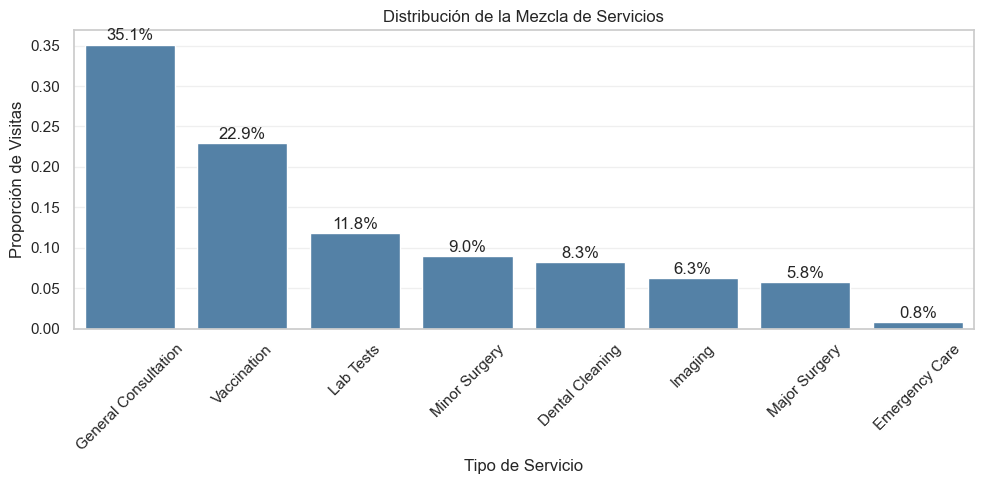

In [10]:
"""
Validación de Mezcla de Servicios
"""

service_mix = visits_df["service_type"].value_counts(normalize=True)

plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=service_mix.index,
    y=service_mix.values,
    color="steelblue"
)

plt.title("Distribución de la Mezcla de Servicios")
plt.xlabel("Tipo de Servicio")
plt.ylabel("Proporción de Visitas")

plt.xticks(rotation=45)

for i, v in enumerate(service_mix.values):
    ax.text(
        i,
        v + 0.005,
        f"{v:.1%}",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)

save_plot("service_mix_distribution")

plt.tight_layout()

plt.show()

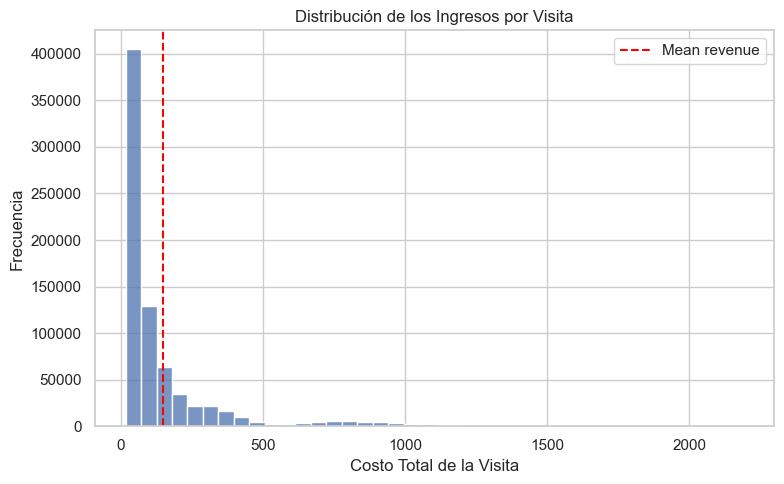

In [11]:
"""
Distribución de Ingresos por Visita
"""

plt.figure(figsize=(8,5))

sns.histplot(
    visits_df["total_visit_cost"],
    bins=40
)

plt.title("Distribución de los Ingresos por Visita")
plt.xlabel("Costo Total de la Visita")
plt.ylabel("Frecuencia")
plt.axvline(
    visits_df["total_visit_cost"].mean(),
    color="red",
    linestyle="--",
    label="Média por visita"
)

plt.legend()

save_plot("visit_revenue_distribution")

plt.tight_layout()

plt.show()

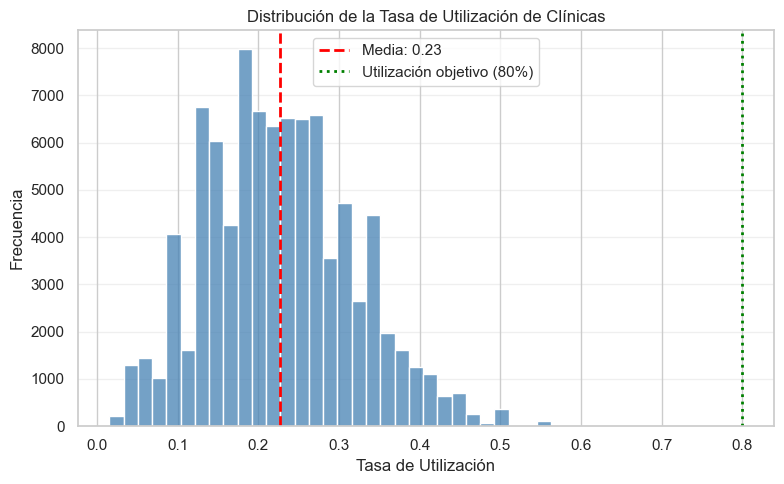

In [12]:
"""
Distribución de la Tasa de Utilización de Clínicas
"""

plt.figure(figsize=(8,5))

sns.histplot(
    daily_metrics_df["vet_utilization_rate"],
    bins=40,
    color="steelblue"
)

mean_util = daily_metrics_df["vet_utilization_rate"].mean()

plt.axvline(
    mean_util,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Media: {mean_util:.2f}"
)

plt.axvline(
    0.8,
    color="green",
    linestyle=":",
    linewidth=2,
    label="Utilización objetivo (80%)"
)

plt.title("Distribución de la Tasa de Utilización de Clínicas")
plt.xlabel("Tasa de Utilización")
plt.ylabel("Frecuencia")

plt.legend()

plt.grid(axis="y", alpha=0.3)

save_plot("clinic_utilization_distribution")

plt.tight_layout()

plt.show()

## Exportar Datasets Generados

Finalmente, exporto todos los datasets generados para que puedan reutilizarse en notebooks posteriores.

Los datasets se guardan en el **directorio data** del proyecto.

In [13]:
"""
Exportar Datasets
"""

cities_df.to_csv("../data/cities.csv", index=False)
clinics_df.to_csv("../data/clinics.csv", index=False)
services_df.to_csv("../data/services.csv", index=False)
pets_df.to_csv("../data/pets.csv", index=False)
calendar_df.to_csv("../data/calendar.csv", index=False)

visits_df.to_csv("../data/visits.csv", index=False)
daily_metrics_df.to_csv("../data/daily_metrics.csv", index=False)

print("Datasets exportados correctamente.")

Datasets exportados correctamente.
